In [41]:
import pandas as pd

df =pd.read_csv('/content/advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [42]:
df.drop('Newspaper', axis=1, inplace=True)

In [43]:
df.head()

,TV,Radio,Sales
0,230.1,37.8,22.1
1,44.5,39.3,10.4
2,17.2,45.9,12.0
3,151.5,41.3,16.5
4,180.8,10.8,17.9


In [44]:

df.describe()

,TV,Radio,Sales
count,200.000000,200.000000,200.000000
mean,147.042500,23.264000,15.130500
std,85.854236,14.846809,5.283892
min,0.700000,0.000000,1.600000
25%,74.375000,9.975000,11.000000
50%,149.750000,22.900000,16.000000
75%,218.825000,36.525000,19.050000
max,296.400000,49.600000,27.000000


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Radio   200 non-null    float64
 2   Sales   200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


In [47]:
from sklearn.model_selection import train_test_split
x = df[['TV','Radio']]
y = df['Sales']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [48]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [49]:
prediction = model.predict(x_test)

In [50]:
print(model.coef_)

[0.05360953 0.10653078]


In [51]:
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test,prediction)
r2_score=r2_score(y_test,prediction)
print('mse:',mse)
print('r2-score:',r2_score)


mse: 2.4081649798649596
r2-score: 0.9139189919346897


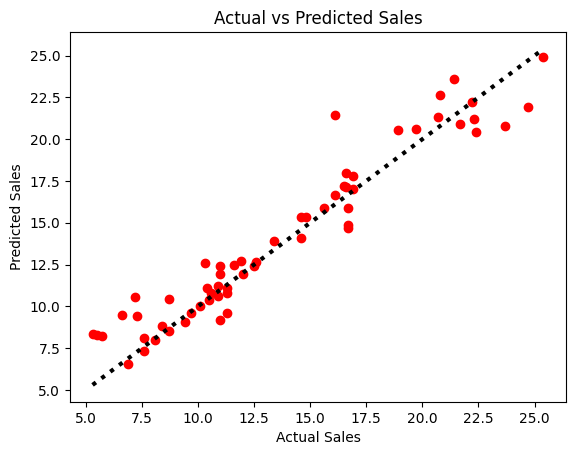

In [59]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt

plt.scatter(y_test, prediction,color='red')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],linestyle="dotted",color="black",lw=3)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [61]:
tv = float(input("TV budget: "))
radio = float(input("Radio budget: "))

prediction = model.predict([[tv, radio]])

print("Expected Sales:", prediction)

TV budget: 300
Radio budget: 22
Expected Sales: [23.31858648]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
